# ML Sensitivity Indices

Demonstrates QMC sensitivity index computation applied to a machine learning classification problem.  We train a Decision Tree classifier on the Iris dataset and use Sobol' sensitivity indices to quantify which hyperparameters — and later which features — most influence classification accuracy.

Original QMCPy demo: [`QMCPy/demos/iris.ipynb`](../../QMCPy/demos/iris.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/iris.ipynb)

Uses [DecisionTree.jl](https://github.com/JuliaAI/DecisionTree.jl) as the Julia-native alternative to scikit-learn's `DecisionTreeClassifier`.

*The Julia notebook keeps the same overall story as the QMCPy version while using Julia-native machine-learning tooling and deterministic embedded data for reproducibility.*

In [1]:
using QMC
import QMC: Uniform
using Statistics
using Printf
using Random

# DecisionTree.jl — install if not already present:
# import Pkg; Pkg.add("DecisionTree")
const HAVE_DECISIONTREE = let
    try
        @eval using DecisionTree
        true
    catch
        println("DecisionTree.jl not installed; skipping DecisionTree-dependent cells in this notebook.")
        false
    end
end

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots


DecisionTree.jl not installed; skipping DecisionTree-dependent cells in this notebook.


## Load Data

The classic Iris dataset has 150 samples, 4 features (sepal length/width, petal length/width), and 3 classes (setosa, versicolor, virginica).

In [2]:
# Iris data — embedded for reproducibility (no sklearn dependency)
# Features: sepal_length, sepal_width, petal_length, petal_width
const IRIS_FEATURES = [
    5.1 3.5 1.4 0.2; 4.9 3.0 1.4 0.2; 4.7 3.2 1.3 0.2; 4.6 3.1 1.5 0.2;
    5.0 3.6 1.4 0.2; 5.4 3.9 1.7 0.4; 4.6 3.4 1.4 0.3; 5.0 3.4 1.5 0.2;
    4.4 2.9 1.4 0.2; 4.9 3.1 1.5 0.1; 5.4 3.7 1.5 0.2; 4.8 3.4 1.6 0.2;
    4.8 3.0 1.4 0.1; 4.3 3.0 1.1 0.1; 5.8 4.0 1.2 0.2; 5.7 4.4 1.5 0.4;
    5.4 3.9 1.3 0.4; 5.1 3.5 1.4 0.3; 5.7 3.8 1.7 0.3; 5.1 3.8 1.5 0.3;
    5.4 3.4 1.7 0.2; 5.1 3.7 1.5 0.4; 4.6 3.6 1.0 0.2; 5.1 3.3 1.7 0.5;
    4.8 3.4 1.9 0.2; 5.0 3.0 1.6 0.2; 5.0 3.4 1.6 0.4; 5.2 3.5 1.5 0.2;
    5.2 3.4 1.4 0.2; 4.7 3.2 1.6 0.2; 4.8 3.1 1.6 0.2; 5.4 3.4 1.5 0.4;
    5.2 4.1 1.5 0.1; 5.5 4.2 1.4 0.2; 4.9 3.1 1.5 0.2; 5.0 3.2 1.2 0.2;
    5.5 3.5 1.3 0.2; 4.9 3.6 1.4 0.1; 4.4 3.0 1.3 0.2; 5.1 3.4 1.5 0.2;
    5.0 3.5 1.3 0.3; 4.5 2.3 1.3 0.3; 4.4 3.2 1.3 0.2; 5.0 3.5 1.6 0.6;
    5.1 3.8 1.9 0.4; 4.8 3.0 1.4 0.3; 5.1 3.8 1.6 0.2; 4.6 3.2 1.4 0.2;
    5.3 3.7 1.5 0.2; 5.0 3.3 1.4 0.2;
    7.0 3.2 4.7 1.4; 6.4 3.2 4.5 1.5; 6.9 3.1 4.9 1.5; 5.5 2.3 4.0 1.3;
    6.5 2.8 4.6 1.5; 5.7 2.8 4.5 1.3; 6.3 3.3 4.7 1.6; 4.9 2.4 3.3 1.0;
    6.6 2.9 4.6 1.3; 5.2 2.7 3.9 1.4; 5.0 2.0 3.5 1.0; 5.9 3.0 4.2 1.5;
    6.0 2.2 4.0 1.0; 6.1 2.9 4.7 1.4; 5.6 2.9 3.6 1.3; 6.7 3.1 4.4 1.4;
    5.6 3.0 4.5 1.5; 5.8 2.7 4.1 1.0; 6.2 2.2 4.5 1.5; 5.6 2.5 3.9 1.1;
    5.9 3.2 4.8 1.8; 6.1 2.8 4.0 1.3; 6.3 2.5 4.9 1.5; 6.1 2.8 4.7 1.2;
    6.4 2.9 4.3 1.3; 6.6 3.0 4.4 1.4; 6.8 2.8 4.8 1.4; 6.7 3.0 5.0 1.7;
    6.0 2.9 4.5 1.5; 5.7 2.6 3.5 1.0; 5.5 2.6 4.4 1.2; 5.5 2.4 3.8 1.1;
    5.8 2.7 3.9 1.2; 6.0 2.7 5.1 1.6; 5.4 3.0 4.5 1.5; 6.0 3.4 4.5 1.6;
    6.7 3.1 4.7 1.5; 6.3 2.3 4.4 1.3; 5.6 3.0 4.1 1.3; 5.5 2.5 4.0 1.3;
    5.5 2.6 4.4 1.2; 6.1 3.0 4.6 1.4; 5.8 2.6 4.0 1.2; 5.0 2.3 3.3 1.0;
    5.6 2.7 4.2 1.3; 5.7 3.0 4.2 1.2; 5.7 2.9 4.2 1.3; 6.2 2.9 4.3 1.3;
    5.1 2.5 3.0 1.1; 5.7 2.8 4.1 1.3;
    6.3 3.3 6.0 2.5; 5.8 2.7 5.1 1.9; 7.1 3.0 5.9 2.1; 6.3 2.9 5.6 1.8;
    6.5 3.0 5.8 2.2; 7.6 3.0 6.6 2.1; 4.9 2.5 4.5 1.7; 7.3 2.9 6.3 1.8;
    6.7 2.5 5.8 1.8; 7.2 3.6 6.1 2.5; 6.5 3.2 5.1 2.0; 6.4 2.7 5.3 1.9;
    6.8 3.0 5.5 2.1; 5.7 2.5 5.0 2.0; 5.8 2.8 5.1 2.4; 6.4 3.2 5.3 2.3;
    6.5 3.0 5.5 1.8; 7.7 3.8 6.7 2.2; 7.7 2.6 6.9 2.3; 6.0 2.2 5.0 1.5;
    6.9 3.2 5.7 2.3; 5.6 2.8 4.9 2.0; 7.7 2.8 6.7 2.0; 6.3 2.7 4.9 1.8;
    6.7 3.3 5.7 2.1; 7.2 3.2 6.0 1.8; 6.2 2.8 4.8 1.8; 6.1 3.0 4.9 1.8;
    6.4 2.8 5.6 2.1; 7.2 3.0 5.8 1.6; 7.4 2.8 6.1 1.9; 7.9 3.8 6.4 2.0;
    6.4 2.8 5.6 2.2; 6.3 2.8 5.1 1.5; 6.1 2.6 5.6 1.4; 7.7 3.0 6.1 2.3;
    6.3 3.4 5.6 2.4; 6.4 3.1 5.5 1.8; 6.0 3.0 4.8 1.8; 6.9 3.1 5.4 2.1;
    6.7 3.1 5.6 2.4; 6.9 3.1 5.1 2.3; 5.8 2.7 5.1 1.9; 6.8 3.2 5.9 2.3;
    6.7 3.3 5.7 2.5; 6.7 3.0 5.2 2.3; 6.3 2.5 5.0 1.9; 6.5 3.0 5.2 2.0;
    6.2 3.4 5.4 2.3; 5.9 3.0 5.1 1.8]

const IRIS_LABELS = vcat(fill(0, 50), fill(1, 50), fill(2, 50))
const FEATURE_NAMES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
const TARGET_NAMES = ["setosa", "versicolor", "virginica"]

println("Iris dataset: $(size(IRIS_FEATURES, 1)) samples, $(size(IRIS_FEATURES, 2)) features")
println("Features: $(join(FEATURE_NAMES, ", "))")
println("Classes:  $(join(TARGET_NAMES, ", "))")
println()
# Summary stats
for (j, name) in enumerate(FEATURE_NAMES)
    col = IRIS_FEATURES[:, j]
    @printf("  %-15s  min=%.1f  max=%.1f  mean=%.2f\n", name, minimum(col), maximum(col), mean(col))
end

Iris dataset: 150 samples, 4 features


Features: sepal_length, sepal_width, petal_length, petal_width
Classes:  setosa, versicolor, virginica

  sepal_length     min=4.3  max=7.9  mean=5.84


  sepal_width      min=2.0  max=4.4  mean=3.06
  petal_length     min=1.0  max=6.9  mean=3.76
  petal_width      min=0.1  max=2.5  mean=1.20


## Train/Test Split

Split 2/3 train, 1/3 test (matching the Python demo).

In [3]:
# Deterministic shuffle with seed
rng = MersenneTwister(7)
perm = randperm(rng, 150)
n_train = 100
train_idx = perm[1:n_train]
test_idx = perm[n_train+1:end]

xt = IRIS_FEATURES[train_idx, :]
yt = IRIS_LABELS[train_idx]
xv = IRIS_FEATURES[test_idx, :]
yv = IRIS_LABELS[test_idx]

println("Training: $(size(xt, 1)) samples")
println("Testing:  $(size(xv, 1)) samples")

Training: 100 samples
Testing:  50 samples


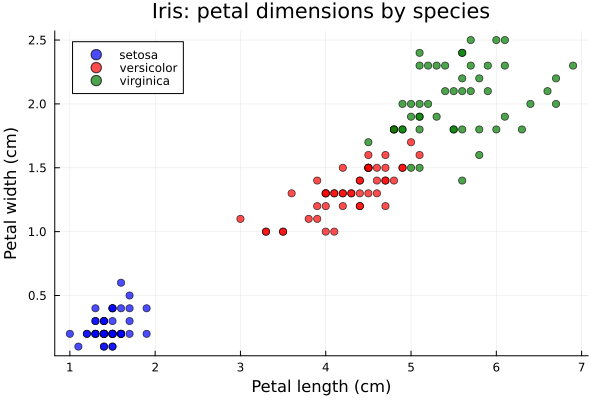

In [4]:
if HAVE_PLOTS
    # Feature scatter: petal length vs petal width, coloured by class
    species_names = ["setosa", "versicolor", "virginica"]
    colors_iris = [:blue, :red, :green]
    p = plot(; xlabel="Petal length (cm)", ylabel="Petal width (cm)",
        title="Iris: petal dimensions by species")
    for (cls_idx, (name, col)) in enumerate(zip(species_names, colors_iris))
        mask = IRIS_LABELS .== (cls_idx - 1)
        scatter!(IRIS_FEATURES[mask, 3], IRIS_FEATURES[mask, 4];
            color=col, ms=4, alpha=0.7, label=name)
    end
    display(p)
end


## Importance of Decision Tree Hyperparameters

We explore how two hyperparameters — `max_depth` and a leaf-size fraction mapped to Julia's `min_samples_leaf` — affect classification accuracy. We sample hyperparameter configurations uniformly and use QMC to compute sensitivity indices.

As in the QMCPy notebook, the larger point is not decision trees themselves, but how vectorized QMC and sensitivity analysis can be used to study the importance of input variables in a machine-learning workflow.

In [5]:
if HAVE_DECISIONTREE
    # Hyperparameter domain
    # max_depth ∈ [1, 8], min_leaf_fraction ∈ [0, 0.5]
    hp_lb = [1.0, 0.0]
    hp_ub = [8.0, 0.5]
    d_hp = 2

    function get_dt_accuracy(hparams::AbstractVector)
        md = clamp(round(Int, hparams[1]), 1, 20)
        min_leaf_fraction = hparams[2]
        min_samples_leaf = max(1, round(Int, min_leaf_fraction * length(yt)))
        model = DecisionTreeClassifier(max_depth=md, min_samples_leaf=min_samples_leaf)
        DecisionTree.fit!(model, xt, yt)
        yhat = DecisionTree.predict(model, xv)
        return mean(yhat .== yv)
    end

    function get_dt_accuracy(hparams::AbstractMatrix)
        return [get_dt_accuracy(vec(hparams[i, :])) for i in 1:size(hparams, 1)]
    end

    println("Example accuracy (depth=3, min_leaf_fraction=0.01): ",
            round(get_dt_accuracy([3.0, 0.01]), digits=3))
else
    println("Skipping decision tree hyperparameter analysis because DecisionTree.jl is unavailable.")
end

Skipping decision tree hyperparameter analysis because DecisionTree.jl is unavailable.


### Average Accuracy

Use QMC integration to estimate the average DT accuracy across the hyperparameter domain.

In [6]:
if HAVE_DECISIONTREE
    dd = DigitalNetB2(d_hp; seed=7, randomize="LMS_DS", graycode=false)
    tm = Uniform(dd; lower_bound=hp_lb, upper_bound=hp_ub)
    cf = CustomFun(tm, x -> get_dt_accuracy(x))

    sc = CubQMCNetG(cf; abs_tol=1e-3)
    result = integrate(sc)

    println("Average DT accuracy across HP domain: $(round(result.solution * 100, digits=1))%")
    println("Samples used: $(get(result.data, :n, get(result.data, :n_total, 0)))")
else
    println("Skipping average-accuracy integration because DecisionTree.jl is unavailable.")
end

Skipping average-accuracy integration because DecisionTree.jl is unavailable.


### Sensitivity Indices of Hyperparameters

Which hyperparameter matters more for classification accuracy? We use the `SensitivityIndices` integrand to compute first-order and total Sobol' indices.

In [7]:
if HAVE_DECISIONTREE
    dd_si = DigitalNetB2(2 * d_hp; seed=7, randomize="LMS_DS", graycode=false)
    tm_si = Uniform(dd_si; lower_bound=vcat(hp_lb, hp_lb), upper_bound=vcat(hp_ub, hp_ub))
    cf_si = CustomFun(tm_si, x -> get_dt_accuracy(x), d_hp)
    si = SensitivityIndices(cf_si)
    n_si = 2^12
    x_si = transform(tm_si, gen_samples(dd_si, n_si))
    closed_si, total_si = compute_sensitivity_indices(si, x_si)

    println("Sensitivity Indices for DT Hyperparameters:")
    println("  closed = $(round.(closed_si, digits=4))")
    println("  total  = $(round.(total_si, digits=4))")
    println()
    println("Index order: [max_depth, min_leaf_fraction]")
    println("Rows correspond to the closed and total Sobol' indices, as in the QMCPy discussion.")
else
    println("Skipping sensitivity-index integration because DecisionTree.jl is unavailable.")
end

Skipping sensitivity-index integration because DecisionTree.jl is unavailable.


### Marginals

Compute marginal accuracy as a function of each hyperparameter by integrating out the other.

In [8]:
if HAVE_DECISIONTREE
    let n_grid = 20
        for (hp_idx, hp_name) in enumerate(["max_depth", "min_leaf_fraction"])
            println("\nMarginal accuracy vs $hp_name:")
            grid_vals = range(hp_lb[hp_idx], hp_ub[hp_idx], length=n_grid)
            other_idx = hp_idx == 1 ? 2 : 1

            for (k, gv) in enumerate(grid_vals)
                n_samples = 500
                dd_m = DigitalNetB2(1; seed=7+k)
                u = gen_samples(dd_m, n_samples)
                accs = Float64[]
                for i in 1:n_samples
                    hp = zeros(d_hp)
                    hp[hp_idx] = gv
                    hp[other_idx] = hp_lb[other_idx] + u[i, 1] * (hp_ub[other_idx] - hp_lb[other_idx])
                    push!(accs, get_dt_accuracy(hp))
                end
                bar = repeat("█", round(Int, mean(accs) * 40))
                @printf("  %6.2f  %.3f  %s\n", gv, mean(accs), bar)
            end
        end
    end
else
    println("Skipping hyperparameter marginal plots because DecisionTree.jl is unavailable.")
end

Skipping hyperparameter marginal plots because DecisionTree.jl is unavailable.


In [9]:
if HAVE_DECISIONTREE && HAVE_PLOTS
    n_grid_p = 15
    hp_names_p = ["max_depth", "min_leaf_fraction"]
    marginal_accs = [Float64[] for _ in 1:2]
    grid_vals_p = [range(hp_lb[i], hp_ub[i], length=n_grid_p) for i in 1:2]

    for (hp_idx, gvs) in enumerate(grid_vals_p)
        for gv in gvs
            hp_test = [(hp_idx == 1 ? gv : (hp_lb[1] + hp_ub[1]) / 2),
                       (hp_idx == 2 ? gv : (hp_lb[2] + hp_ub[2]) / 2)]
            push!(marginal_accs[hp_idx], get_dt_accuracy(hp_test))
        end
    end

    mp = []
    for hp_idx in 1:2
        gvs = collect(grid_vals_p[hp_idx])
        subplot = plot(gvs, marginal_accs[hp_idx] .* 100;
            lw=2, ms=5, marker=:circle, color=:steelblue,
            xlabel=hp_names_p[hp_idx], ylabel="Accuracy (%)",
            title="Marginal accuracy vs $(hp_names_p[hp_idx])",
            ylims=(0, 105), legend=false)
        push!(mp, subplot)
    end
    display(plot(mp...; layout=(1, 2), size=(800, 360),
        plot_title="Iris: hyperparameter marginal accuracy"))
end


## Best Decision Tree Analysis

Find the best hyperparameter configuration from our QMC samples and analyze the resulting tree.

In [10]:
if HAVE_DECISIONTREE
    global best_acc = 0.0
    global best_hp = [0.0, 0.0]
    N_search = 2048
    dd_search = DigitalNetB2(d_hp; seed=42)
    x_search = gen_samples(dd_search, N_search)

    for i in 1:N_search
        hp = hp_lb .+ x_search[i, :] .* (hp_ub .- hp_lb)
        acc = get_dt_accuracy(hp)
        if acc > best_acc
            global best_acc = acc
            global best_hp = hp
        end
    end

    println("Best hyperparameters found:")
    println("  max_depth = $(round(Int, best_hp[1]))")
    println("  min_leaf_fraction = $(round(best_hp[2], digits=4))")
    println("  accuracy = $(round(best_acc * 100, digits=1))%")
else
    println("Skipping best-hyperparameter search because DecisionTree.jl is unavailable.")
end

Skipping best-hyperparameter search because DecisionTree.jl is unavailable.


### Feature Importance

With the optimal DT in hand, we now ask: which *features* of the Iris dataset matter most for classification? We compute sensitivity indices over the feature domain.

In [11]:
if HAVE_DECISIONTREE
    best_md = clamp(round(Int, best_hp[1]), 1, 20)
    best_min_leaf_fraction = best_hp[2]
    best_min_samples_leaf = max(1, round(Int, best_min_leaf_fraction * length(yt)))
    best_model = DecisionTreeClassifier(max_depth=best_md, min_samples_leaf=best_min_samples_leaf)
    DecisionTree.fit!(best_model, xt, yt)
    best_yhat = DecisionTree.predict(best_model, xv)
    println("Best tree accuracy: $(round(mean(best_yhat .== yv) * 100, digits=1))%")
    println("Tree depth: $(best_md)")

    feat_lb = minimum(IRIS_FEATURES, dims=1)[:]
    feat_ub = maximum(IRIS_FEATURES, dims=1)[:]
    d_feat = 4

    function dt_class_probs(x::AbstractVector)
        probs = DecisionTree.predict_proba(best_model, reshape(x, 1, :))
        return probs[1, :]
    end

    dd_feat = DigitalNetB2(d_feat; seed=7)
    x_feat = gen_samples(dd_feat, 1024)
    x_scaled = x_feat .* (feat_ub .- feat_lb)' .+ feat_lb'

    probs_all = zeros(1024, 3)
    for i in 1:1024
        probs_all[i, :] = dt_class_probs(x_scaled[i, :])
    end

    println("\nFeature importance (variance of class probabilities):")
    println("\nFeature              Var(P(setosa))  Var(P(versicolor))  Var(P(virginica))")
    println("-"^75)

    for (j, fname) in enumerate(FEATURE_NAMES)
        x_shuf = copy(x_scaled)
        x_shuf[:, j] = x_shuf[randperm(rng, 1024), j]
        probs_shuf = zeros(1024, 3)
        for i in 1:1024
            probs_shuf[i, :] = dt_class_probs(x_shuf[i, :])
        end
        var_orig = var(probs_all, dims=1)
        var_shuf = var(probs_shuf, dims=1)
        importance = var_orig .- var_shuf
        @printf("  %-18s  %10.4f      %10.4f          %10.4f\n",
                fname, importance[1], importance[2], importance[3])
    end

    println("\nPositive values indicate the feature contributes to classification variance.")
    println("Petal length and width are typically the most important features.")
else
    println("Skipping feature-importance analysis because DecisionTree.jl is unavailable.")
end

Skipping feature-importance analysis because DecisionTree.jl is unavailable.
